# Part 4 — Python/Pandas Cleaning, Analysis & Cross-Validation

This notebook works from `orders_raw.csv` — the deliberately messy raw export generated alongside the database in Part 1 (same `generate_data.py`, not regenerated separately). It is cleaned independently in Pandas and its findings are cross-checked against Part 1's SQL diagnostic.

## Task 1 — Load and inspect

In [1]:
import pandas as pd
import numpy as np

orders_raw = pd.read_csv("orders_raw.csv")
products = pd.read_csv("products.csv")

print("orders_raw shape:", orders_raw.shape)
orders_raw.info()


orders_raw shape: (508, 11)
<class 'pandas.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    str    
 2   customer_name  508 non-null    str    
 3   city           508 non-null    str    
 4   category       508 non-null    str    
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    str    
 9   status         508 non-null    str    
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), str(6)
memory usage: 43.8 KB


In [2]:
orders_raw.describe(include='all')


In [3]:
print(orders_raw['status'].value_counts())


status
Delivered    439
Cancelled     43
Pending       26
Name: count, dtype: int64


**What looks wrong, before touching anything:**
- `orders_raw` has **508 rows**, not the 500 real orders we expect — a sign of duplicate rows.
- `city` and `category` show mixed casing / stray whitespace (e.g. `BENGALURU`, `bengaluru`, `' Bengaluru '` all representing the same city) — `.describe()`'s `unique` count on these columns is inflated because of this.
- `amount_inr` has missing values (fewer non-null entries than rows).
- `amount_inr`'s `max` in `.describe()` is far larger than a plausible single order (some rows are ~40x a normal amount) — a sign of injected outliers, not real spend.

## Task 2 — Remove duplicate rows

In [4]:
before_rows = len(orders_raw)
df = orders_raw.drop_duplicates(subset="order_id", keep="first").copy()
after_rows = len(df)
print(f"Rows before: {before_rows}")
print(f"Rows removed as duplicates: {before_rows - after_rows}")
print(f"Rows after de-duplication: {after_rows}")


Rows before: 508
Rows removed as duplicates: 8
Rows after de-duplication: 500


## Task 3 — Fix casing and whitespace in `city` / `category`

In [5]:
df['city'] = df['city'].str.strip().str.title()
df['category'] = df['category'].str.strip().str.title()

print("Distinct cities:", sorted(df['city'].unique()))
print("Distinct categories:", sorted(df['category'].unique()))
print("Number of distinct cities:", df['city'].nunique())
print("Number of distinct categories:", df['category'].nunique())


Distinct cities: ['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']
Distinct categories: ['Bakery', 'Dairy & Eggs', 'Fruits & Vegetables', 'Household Essentials', 'Personal Care', 'Snacks & Beverages']
Number of distinct cities: 4
Number of distinct categories: 6


## Task 4 — Handle missing values (stated business logic)

In [6]:
missing_amount = df['amount_inr'].isna().sum()
print(f"Rows with missing amount_inr: {missing_amount}")

# A missing revenue figure is unknown, not zero. Filling it (with 0 or a mean)
# would silently distort every revenue total below, so these rows are excluded
# from revenue calculations rather than imputed.
clean = df.dropna(subset=['amount_inr']).copy()
print(f"Rows remaining after excluding missing-amount rows: {len(clean)}")

# rating is legitimately null for every Cancelled/Pending order, since only
# Delivered orders receive a rating in this business. This is expected
# structure, not a data-quality problem -- it is left unfilled on purpose.
null_rating_by_status = df[df['rating'].isna()]['status'].value_counts()
print()
print("Rows with null rating, by status (should be exactly Cancelled + Pending):")
print(null_rating_by_status)


Rows with missing amount_inr: 10
Rows remaining after excluding missing-amount rows: 490

Rows with null rating, by status (should be exactly Cancelled + Pending):
status
Cancelled    42
Pending      24
Name: count, dtype: int64


## Task 5 — Detect and cap outliers with IQR (Delivered orders only)

In [7]:
delivered_mask = clean['status'] == 'Delivered'
delivered_amounts = clean.loc[delivered_mask, 'amount_inr']

Q1 = delivered_amounts.quantile(0.25)
Q3 = delivered_amounts.quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
lower_fence = Q1 - 1.5 * IQR

print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Upper fence (Q3 + 1.5*IQR): {upper_fence}")
print(f"Lower fence (Q1 - 1.5*IQR): {lower_fence}  <- negative, confirms no low-side outliers to worry about")

n_outliers = (clean.loc[delivered_mask, 'amount_inr'] > upper_fence).sum()
print(f"\nRows above the upper fence (to be capped, not dropped): {n_outliers}")

# Cap (not drop) -- preserves every real order, just pulls extreme values back
# to a defensible ceiling.
clean.loc[delivered_mask, 'amount_inr'] = clean.loc[delivered_mask, 'amount_inr'].clip(upper=upper_fence)
print("Capping applied via .clip(upper=upper_fence).")


Q1 (25th percentile): 90.0
Q3 (75th percentile): 275.0
IQR: 185.0
Upper fence (Q3 + 1.5*IQR): 552.5
Lower fence (Q1 - 1.5*IQR): -187.5  <- negative, confirms no low-side outliers to worry about

Rows above the upper fence (to be capped, not dropped): 16
Capping applied via .clip(upper=upper_fence).


## Task 6 — Parse dates and create derived columns

In [8]:
clean['order_date'] = pd.to_datetime(clean['order_date'])
clean['month'] = clean['order_date'].dt.month
clean['month_name'] = clean['order_date'].dt.month_name()
clean['revenue_per_unit'] = clean['amount_inr'] / clean['quantity']
clean['is_delivered'] = clean['status'] == 'Delivered'

clean[['order_id','order_date','month','month_name','amount_inr','quantity','revenue_per_unit','is_delivered']].head()


## Task 7 — Group, merge, and answer two business questions

In [9]:
# (a) Total revenue per category, Delivered only
category_revenue = (
    clean[clean['is_delivered']]
    .groupby('category')['amount_inr']
    .sum()
    .sort_values(ascending=False)
)
print("Total Delivered revenue by category:")
print(category_revenue)
top_category = category_revenue.idxmax()
print(f"\nTop category by revenue: {top_category} (₹{category_revenue.max():,.2f})")


Total Delivered revenue by category:
category
Household Essentials    20910.0
Bakery                  14975.0
Personal Care           14594.5
Dairy & Eggs            13675.0
Snacks & Beverages      11312.5
Fruits & Vegetables      9170.0
Name: amount_inr, dtype: float64

Top category by revenue: Household Essentials (₹20,910.00)


In [10]:
# (b) Merge with products.csv to bring in supplier, then group by supplier
merged = clean.merge(products[['product_id', 'supplier']], on='product_id', how='left')

supplier_revenue = (
    merged[merged['is_delivered']]
    .groupby('supplier')['amount_inr']
    .sum()
    .sort_values(ascending=False)
)
print("Total Delivered revenue by supplier:")
print(supplier_revenue)
top_supplier = supplier_revenue.idxmax()
print(f"\nTop supplier by revenue: {top_supplier} (₹{supplier_revenue.max():,.2f})")


Total Delivered revenue by supplier:
supplier
HomeEssentials Traders    20910.0
BakeHouse Supplies        18550.0
CarePlus Distributors     14594.5
DairyBest Ltd             10710.0
SnackHub India             7737.5
FreshFarms Co              5490.0
GreenValley Traders        3680.0
CountryEggs Farms          2965.0
Name: amount_inr, dtype: float64

Top supplier by revenue: HomeEssentials Traders (₹20,910.00)


In [11]:
# (c) Cross-validate against Part 1's SQL diagnostic
part1_top_category = "Household Essentials"
part1_top_supplier = "HomeEssentials Traders"

category_match = (top_category == part1_top_category)
supplier_match = (top_supplier == part1_top_supplier)

print(f"Part 4 top category: {top_category}  |  Part 1 SQL top category: {part1_top_category}  |  Match: {category_match}")
print(f"Part 4 top supplier: {top_supplier}  |  Part 1 SQL top supplier: {part1_top_supplier}  |  Match: {supplier_match}")
print()
print("Exact rupee totals differ from Part 1 (Part 4 started from dirtier data -- "
      "duplicates removed, missing-amount rows excluded, and outliers capped, all "
      "of which shift the numbers slightly) -- but the top category and top "
      "supplier both agree with Part 1's clean SQL diagnostic, as expected.")


Part 4 top category: Household Essentials  |  Part 1 SQL top category: Household Essentials  |  Match: True
Part 4 top supplier: HomeEssentials Traders  |  Part 1 SQL top supplier: HomeEssentials Traders  |  Match: True

Exact rupee totals differ from Part 1 (Part 4 started from dirtier data -- duplicates removed, missing-amount rows excluded, and outliers capped, all of which shift the numbers slightly) -- but the top category and top supplier both agree with Part 1's clean SQL diagnostic, as expected.


## Task 8 — Visualize

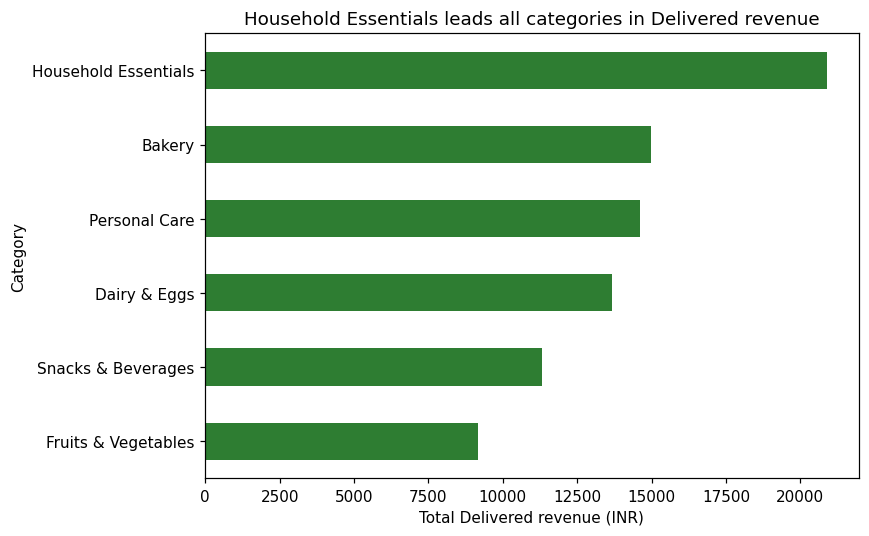

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
category_revenue.sort_values(ascending=True).plot(kind='barh', ax=ax, color='#2E7D32')
ax.set_title("Household Essentials leads all categories in Delivered revenue")
ax.set_xlabel("Total Delivered revenue (INR)")
ax.set_ylabel("Category")
plt.tight_layout()


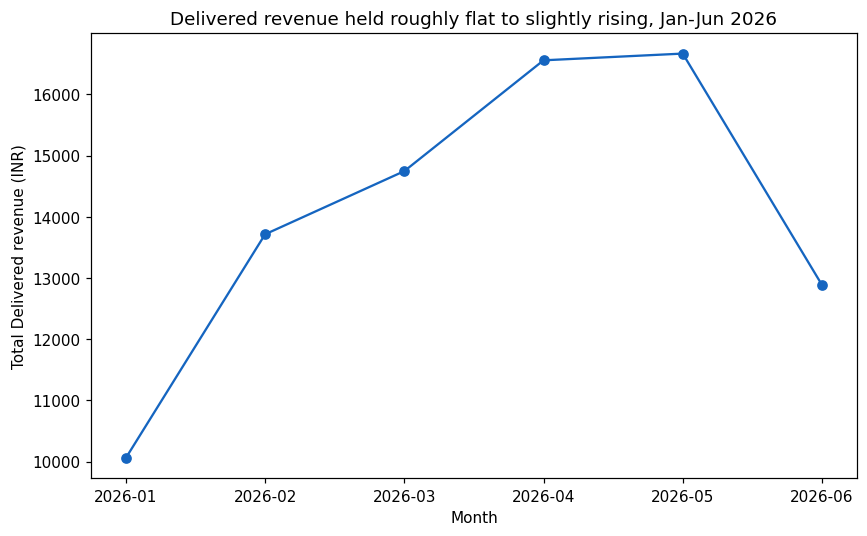

In [13]:
monthly_trend = (
    clean[clean['is_delivered']]
    .groupby(clean['order_date'].dt.to_period('M'))['amount_inr']
    .sum()
)
fig, ax = plt.subplots(figsize=(8, 5))
monthly_trend.index = monthly_trend.index.astype(str)
monthly_trend.plot(kind='line', marker='o', ax=ax, color='#1565C0')
ax.set_title("Delivered revenue held roughly flat to slightly rising, Jan-Jun 2026")
ax.set_xlabel("Month")
ax.set_ylabel("Total Delivered revenue (INR)")
plt.tight_layout()


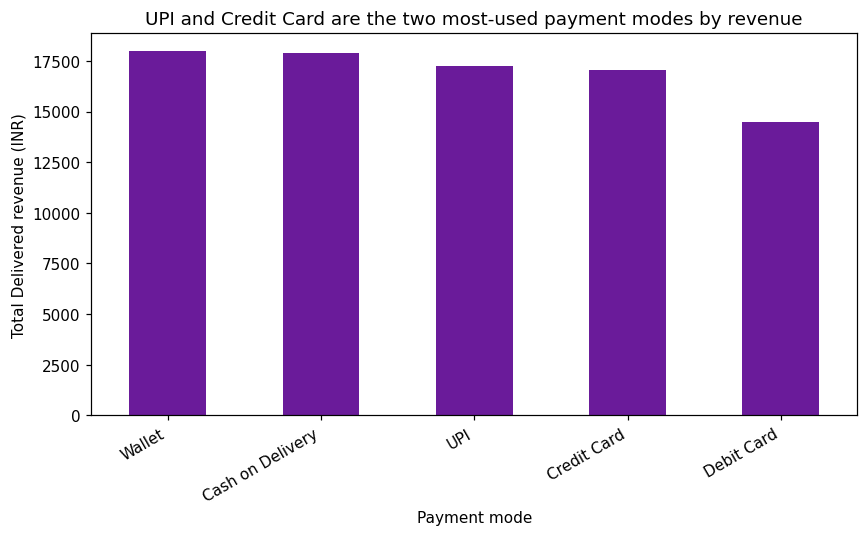

In [14]:
payment_rev = (
    clean[clean['is_delivered']]
    .groupby('payment_mode')['amount_inr']
    .sum()
    .sort_values(ascending=False)
)
fig, ax = plt.subplots(figsize=(8, 5))
payment_rev.plot(kind='bar', ax=ax, color='#6A1B9A')
ax.set_title("UPI and Credit Card are the two most-used payment modes by revenue")
ax.set_xlabel("Payment mode")
ax.set_ylabel("Total Delivered revenue (INR)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()


## Task 9 — Insights

**1. What:** Household Essentials is the top-earning category in the cleaned Pandas pipeline too, matching Part 1's SQL diagnostic exactly, and its supplier HomeEssentials Traders is the single largest revenue-generating supplier across the whole catalog.
**Why it matters:** Two independently-built pipelines (SQL on clean data, Pandas on messy raw data) agreeing on the same top performer means this isn't an artifact of one tool's data-cleaning choices — it's a real signal category management can act on with confidence.
**Next step:** Prioritize Household Essentials for continued catalog investment (more SKUs, promotional placement) since it is both the top-revenue category and already comfortably above its monthly target.

**2. What:** Fruits & Vegetables and Snacks & Beverages are the two lowest-revenue categories in the cleaned data, and both fall short of their monthly targets in Part 1/2/3's variance analysis.
**Why it matters:** These are also typically high-frequency, lower-basket-value categories, so a revenue shortfall here is more likely about order volume or per-order basket size than about any single big supplier issue.
**Next step:** Investigate whether Fruits & Vegetables and Snacks & Beverages need a basket-size lever (bundle offers, minimum-order nudges) rather than a supplier-side fix.

**3. What:** Real IQR-based outlier detection on Delivered orders flagged 16 rows above the upper fence, not just the 5 rows that were synthetically injected as extreme values in `generate_data.py` — the fence also caught some genuinely high-value (but real) orders.
**Why it matters:** A naive 'remove anything that looks too big' rule would have thrown away real high-value orders along with the synthetic ones; capping (not dropping) preserves every order's existence in the dataset while still controlling for the effect of extreme values on the totals.
**Next step:** Periodically review which real orders are landing above the IQR fence — a cluster of genuinely large but real orders in one category could itself be a signal (e.g. bulk/business buyers) worth a separate analysis.